# Machine Translation

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
from collections import Counter
import torch.nn.functional as F

import random
import math

torch.manual_seed(0)
random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
!wget https://www.manythings.org/anki/ukr-eng.zip
!unzip -o ukr-eng.zip

In [ ]:
lines = open("ukr.txt", encoding="utf-8").read().split("\n")
print(lines[0])
print()

pairs = []
for line in lines:
    parts = line.split("\t")
    if len(parts) < 2:
        continue
    eng = parts[0].strip()
    ukr = parts[1].strip()
    pairs.append((ukr, eng))

print(pairs[0])
print(len(pairs))
print()

for _ in range(5):
    print(random.choice(pairs))

Go.	Йди.	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #6584257 (deniko)

('Йди.', 'Go.')
160049

('Визнаю, що я втомилася.', "I admit that I'm tired.")
('А тепер у нас проблеми.', "Now we're in trouble.")
('Тома забрала до лікарні.', 'Tom has been taken to a hospital.')
('Я ненавиджу будь-яку музику.', 'I hate all music.')
('Я не дозволю Тому знову це зробити.', "I won't let Tom do that again.")


In [ ]:
MAX_VOCAB = 15000
specials = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]


def tokenize(text):
    return text.lower().strip().split()

In [ ]:
def build_vocab(sentences):
    counter = Counter()

    for s in sentences:
        counter.update(tokenize(s))

    most_common = counter.most_common(MAX_VOCAB - len(specials))
    itos = specials + [w for w, _ in most_common]
    stoi = {w: i for i, w in enumerate(itos)}

    return stoi, itos

In [ ]:
ukr_sentences = [p[0] for p in pairs]
eng_sentences = [p[1] for p in pairs]

eng_stoi, eng_itos = build_vocab(eng_sentences)
ukr_stoi, ukr_itos = build_vocab(ukr_sentences)

PAD_IDX = eng_stoi["[PAD]"]
UNK_IDX = eng_stoi["[UNK]"]
BOS_IDX = eng_stoi["[BOS]"]
EOS_IDX = eng_stoi["[EOS]"]

print("ENG vocab size:", len(eng_stoi))
print("UKR vocab size:", len(ukr_stoi))

ENG vocab size: 15000
UKR vocab size: 15000


In [ ]:
MAX_LEN_SRC = 20
MAX_LEN_TGT = 20

def encode(text, stoi, add_specials=False):
    tokens = tokenize(text)
    ids = []

    if add_specials:
        ids.append(BOS_IDX)

    for t in tokens:
        ids.append(stoi.get(t, UNK_IDX))

    if add_specials:
        ids.append(EOS_IDX)

    return ids

In [ ]:
def prepare_pair(src_text, tgt_text):
    src = encode(src_text, ukr_stoi, add_specials=False)

    tgt_full = encode(tgt_text, eng_stoi, add_specials=True)

    tgt_in = tgt_full[:-1]
    tgt_out = tgt_full[1:]

    src = src[:MAX_LEN_SRC] + [PAD_IDX] * (MAX_LEN_SRC - len(src))
    tgt_in = tgt_in[:MAX_LEN_TGT] + [PAD_IDX] * (MAX_LEN_TGT - len(tgt_in))
    tgt_out = tgt_out[:MAX_LEN_TGT] + [PAD_IDX] * (MAX_LEN_TGT - len(tgt_out))

    return src, tgt_in, tgt_out

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]
        src, tgt_in, tgt_out = prepare_pair(src_text, tgt_text)

        return (
            torch.tensor(src, dtype=torch.long),
            torch.tensor(tgt_in, dtype=torch.long),
            torch.tensor(tgt_out, dtype=torch.long),
        )

In [ ]:
random.shuffle(pairs)

total = len(pairs)
train_size = int(0.95 * total)


train_pairs = pairs[:train_size]
val_pairs   = pairs[train_size : ]


print("Train:", len(train_pairs))
print("Val:", len(val_pairs))

print("Total:", len(train_pairs) + len(val_pairs))

Train: 152046
Val: 8003
Total: 160049


In [ ]:
train_ds = TranslationDataset(train_pairs)
val_ds   = TranslationDataset(val_pairs)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

In [ ]:
src, tgt_in, tgt_out = next(iter(train_loader))
print("src:", src.shape)       # [B, MAX_LEN_SRC]
print("tgt_in:", tgt_in.shape) # [B, MAX_LEN_TGT]
print("tgt_out:", tgt_out.shape)

src: torch.Size([64, 20])
tgt_in: torch.Size([64, 20])
tgt_out: torch.Size([64, 20])


In [ ]:
def make_padding_mask(x, pad_idx=PAD_IDX):
    return (x == pad_idx)

def generate_subsequent_mask(size, device):
    mask = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return mask

class TokenPositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len=50, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, T]
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        x = self.token_emb(x) + self.pos_emb(pos)
        return self.dropout(x)

In [ ]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self,
                 src_vocab_size,
                 tgt_vocab_size,
                 d_model=64,
                 n_heads=4,
                 num_layers=2,
                 d_ff=128,
                 max_len_src=20,
                 max_len_tgt=20,
                 dropout=0.1):
        super().__init__()

        self.src_emb = TokenPositionalEmbedding(src_vocab_size, d_model, max_len_src, dropout)
        self.tgt_emb = TokenPositionalEmbedding(tgt_vocab_size, d_model, max_len_tgt, dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
        )
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
        )

        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)

        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt_in):
        """
        src: [B, S]
        tgt_in: [B, T]
        """
        src_key_padding_mask = make_padding_mask(src)      # [B, S]
        tgt_key_padding_mask = make_padding_mask(tgt_in)   # [B, T]

        # embeddings
        enc_in = self.src_emb(src)     # [B, S, D]
        dec_in = self.tgt_emb(tgt_in)  # [B, T, D]

        # encoder
        memory = self.encoder(
            enc_in,
            src_key_padding_mask=src_key_padding_mask
        )  # [B, S, D]

        T = tgt_in.size(1)
        tgt_mask = generate_subsequent_mask(T, device=tgt_in.device)  # [T,T]

        dec_out = self.decoder(
            dec_in,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )  # [B, T, D]

        logits = self.output_proj(dec_out)  # [B, T, V_tgt]
        return logits

In [ ]:
src_vocab_size = len(ukr_stoi)
tgt_vocab_size = len(eng_stoi)

model = Seq2SeqTransformer(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    d_model=64,
    n_heads=4,
    num_layers=4,
    d_ff=128,
    max_len_src=MAX_LEN_SRC,
    max_len_tgt=MAX_LEN_TGT,
).to(device)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_parameters(model))

Trainable parameters: 3232408


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    n_tokens = 0

    for src, tgt_in, tgt_out in loader:
        src = src.to(device)
        tgt_in = tgt_in.to(device)
        tgt_out = tgt_out.to(device)

        optimizer.zero_grad()

        logits = model(src, tgt_in)  # [B, T, V]
        B, T, V = logits.shape

        loss = criterion(
            logits.view(B*T, V),
            tgt_out.view(B*T)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * (tgt_out != PAD_IDX).sum().item()
        n_tokens += (tgt_out != PAD_IDX).sum().item()

    return total_loss / n_tokens


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n_tokens = 0

    for src, tgt_in, tgt_out in loader:
        src = src.to(device)
        tgt_in = tgt_in.to(device)
        tgt_out = tgt_out.to(device)

        logits = model(src, tgt_in)
        B, T, V = logits.shape

        loss = criterion(
            logits.view(B*T, V),
            tgt_out.view(B*T)
        )

        total_loss += loss.item() * (tgt_out != PAD_IDX).sum().item()
        n_tokens += (tgt_out != PAD_IDX).sum().item()

    return total_loss / n_tokens


In [ ]:
EPOCHS = 10

for ep in range(1, EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {ep}/{EPOCHS} - train loss/token: {train_loss:.4f}  val loss/token: {val_loss:.4f}")

Epoch 1/10 - train loss/token: 1.8444  val loss/token: 1.6949
Epoch 2/10 - train loss/token: 1.6483  val loss/token: 1.5765
Epoch 3/10 - train loss/token: 1.5032  val loss/token: 1.4868
Epoch 4/10 - train loss/token: 1.3951  val loss/token: 1.4196
Epoch 5/10 - train loss/token: 1.3084  val loss/token: 1.3653
Epoch 6/10 - train loss/token: 1.2374  val loss/token: 1.3146
Epoch 7/10 - train loss/token: 1.1780  val loss/token: 1.2908
Epoch 8/10 - train loss/token: 1.1262  val loss/token: 1.2476
Epoch 9/10 - train loss/token: 1.0815  val loss/token: 1.2336
Epoch 10/10 - train loss/token: 1.0419  val loss/token: 1.2055


In [ ]:
def encode_src_sentence(text, stoi, max_len):
    tokens = tokenize(text)
    ids = [stoi.get(t, UNK_IDX) for t in tokens]
    ids = ids[:max_len] + [PAD_IDX] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0)


def decode_tgt_ids(ids, itos):
    tokens = []
    for i in ids:
        if i in (PAD_IDX, BOS_IDX, EOS_IDX):
            continue
        tokens.append(itos[i])
    return " ".join(tokens)

In [ ]:
@torch.no_grad()
def translate(model, sentence, max_len=MAX_LEN_TGT):
    model.eval()
    device = next(model.parameters()).device

    src = encode_src_sentence(sentence, ukr_stoi, MAX_LEN_SRC).to(device)
    src_key_padding_mask = make_padding_mask(src)

    enc_in = model.src_emb(src)
    memory = model.encoder(enc_in, src_key_padding_mask=src_key_padding_mask)

    tgt_ids = [BOS_IDX]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_ids, dtype=torch.long, device=device).unsqueeze(0)
        tgt_key_padding_mask = make_padding_mask(tgt_tensor)

        T = tgt_tensor.size(1)
        tgt_mask = generate_subsequent_mask(T, device=device)

        dec_in = model.tgt_emb(tgt_tensor)
        dec_out = model.decoder(
            dec_in, memory, tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )

        logits = model.output_proj(dec_out[:, -1, :])
        next_id = logits.argmax(dim=-1).item()
        tgt_ids.append(next_id)
        if next_id == EOS_IDX:
            break

    translation = decode_tgt_ids(tgt_ids, eng_itos)
    return translation

In [ ]:
examples = [
    "Добрий ранок.",
    "Зелена машина.",
    "Як справи?",
    "Я йду на роботу.",
    "Том сподівається знайти свого кота.",
    "Ми хочемо купити картоплю в магазині",

]

for s in examples:
    print("UKR:", s)
    print("EN:", translate(model, s))
    print()


UKR: Добрий ранок.
EN: good morning.

UKR: Зелена машина.
EN: the green car.

UKR: Як справи?
EN: how are you doing?

UKR: Я йду на роботу.
EN: i'm going to work.

UKR: Том сподівається знайти свого кота.
EN: tom hopes to find his cat.

UKR: Ми хочемо купити картоплю в магазині
EN: we want to buy a driver's license in the camera.



# GAN Fashion MNIST

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),                    # [0,1]
    transforms.Lambda(lambda x: x.view(-1)),  # 784
    transforms.Lambda(lambda x: (x - 0.5) * 2)  # [-1,1]
])

In [ ]:
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

print("train samples:", len(train_dataset))
print("input dim:", train_dataset[0][0].shape[0])  # 784

In [ ]:
input_dim = 784     # 28*28
latent_dim = 100

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, input_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [ ]:
discriminator = Discriminator().to(device)
generator = Generator().to(device)

criterion = nn.BCELoss()

d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999)).

In [ ]:
def plot_generated_images(epoch, generator, num_images=10):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(noise)  # [N, 784]
        fake_images = fake_images.view(-1, 28, 28).cpu().numpy()

    plt.figure(figsize=(10, 1))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = (fake_images[i] + 1) / 2
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Epoch: {epoch}")
    plt.tight_layout()
    plt.show()

    generator.train()

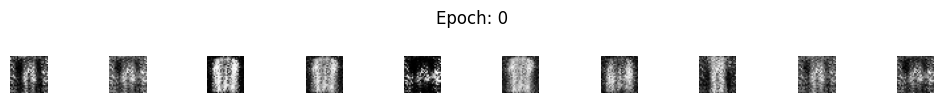

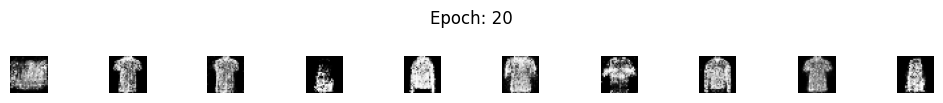

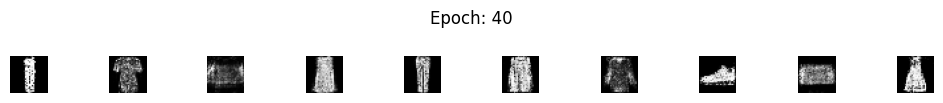

In [ ]:
discrim_losses = []

def train_gan(num_epochs):
    for epoch in range(num_epochs + 1):
        for real_images, _ in train_loader:
            real_images = real_images.to(device)

            batch_size_curr = real_images.size(0)

            real_labels = torch.full((batch_size_curr, 1), 0.9, device=device)
            fake_labels = torch.zeros(batch_size_curr, 1, device=device)

            outputs_real = discriminator(real_images)
            d_loss_real = criterion(outputs_real, real_labels)

            noise = torch.randn(batch_size_curr, latent_dim, device=device)
            fake_images = generator(noise)

            outputs_fake = discriminator(fake_images.detach())
            d_loss_fake = criterion(outputs_fake, fake_labels)

            d_loss = d_loss_real + d_loss_fake

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            discrim_losses.append(d_loss.item())

            noise = torch.randn(batch_size_curr, latent_dim, device=device)
            fake_images = generator(noise)
            outputs = discriminator(fake_images)

            g_loss = criterion(outputs, real_labels)  # хочемо 1

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        if epoch % 20 == 0:
            plot_generated_images(epoch, generator)


num_epochs = 40
train_gan(num_epochs)

# DistilBERT, RoBERTa

In [ ]:
import pandas as pd
from transformers import pipeline
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
import torch
import re, string

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
reviews_df = pd.read_csv('reviews_filtered_balanced.csv')
reviews_df['target'] = reviews_df['rating'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
      return ""
    text = text.lower()
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"https*\S+", " ", text)
    text = re.sub(r"#\S+", " ", text)
    text = re.sub(r"\d", " ", text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s{2,}',' ', text)
    return text

In [ ]:
reviews_df['clean_text'] = reviews_df['review_text'].apply(clean_text)

In [ ]:
model1 = "distilbert-base-uncased-finetuned-sst-2-english"
pipe1 = pipeline("text-classification", model=model1, device=device)
model2 = "cardiffnlp/twitter-roberta-base-sentiment"
pipe2 = pipeline("text-classification", model=model2, device=device)


In [ ]:
def map_distilbert_to_target(pred_label):
    if pred_label == 'POSITIVE': return 1
    else: return 0

def map_roberta_to_target(pred_label):
    if pred_label == 'LABEL_2': return 1      # positive
    elif pred_label == 'LABEL_0': return 0    # negative
    else: return 0

In [ ]:
predictions_model1 = []
predictions_model2 = []

for text in tqdm(reviews_df['clean_text']):
    res1 = pipe1(text, truncation=True, max_length=512)[0]
    predictions_model1.append(map_distilbert_to_target(res1['label']))

    res2 = pipe2(text, truncation=True, max_length=512)[0]
    predictions_model2.append(map_roberta_to_target(res2['label']))

reviews_df['pred_distilbert'] = predictions_model1
reviews_df['pred_roberta'] = predictions_model2
reviews_df.to_csv("results_huggingface.csv", index=False)


In [ ]:
print(model1)
print("Accuracy:", accuracy_score(reviews_df['target'], reviews_df['pred_distilbert']))
print(classification_report(reviews_df['target'], reviews_df['pred_distilbert']))

print(model2)
print("Accuracy:", accuracy_score(reviews_df['target'], reviews_df['pred_roberta']))
print(classification_report(reviews_df['target'], reviews_df['pred_roberta']))

distilbert-base-uncased-finetuned-sst-2-english
Accuracy: 0.8339925992088809
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      3837
           1       0.82      0.86      0.84      4000

    accuracy                           0.83      7837
   macro avg       0.83      0.83      0.83      7837
weighted avg       0.83      0.83      0.83      7837

cardiffnlp/twitter-roberta-base-sentiment
Accuracy: 0.8398621921653694
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      3837
           1       0.79      0.93      0.86      4000

    accuracy                           0.84      7837
   macro avg       0.85      0.84      0.84      7837
weighted avg       0.85      0.84      0.84      7837



# Image2Image

In [ ]:
import torch
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image

pipe = StableDiffusionImg2ImgPipeline.from_pretrained("CompVis/stable-diffusion-v1-4").to("cuda")

Image shape: (747, 1200, 3)


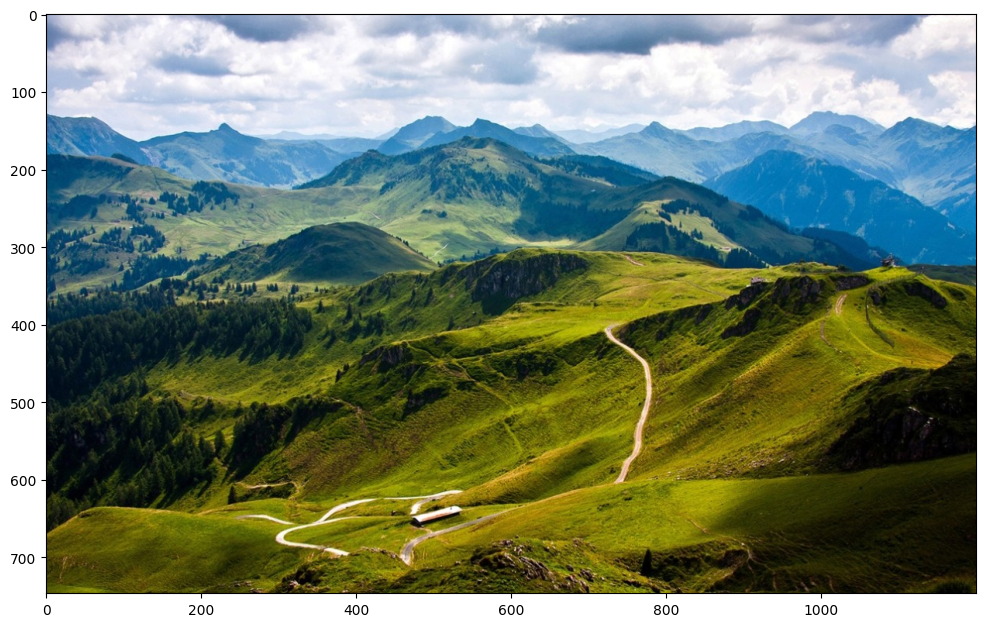

In [ ]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread('1505202877_mountains-1366x768-0061200.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print("Image shape:", img.shape)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.show()

In [ ]:
mnt = Image.fromarray(img)

In [ ]:
prompt = "a harsh winter landscape, heavy deep snow covering everything, blizzard atmosphere, cold blue and grey tones, cinematic photograph, highly detailed"

result = pipe(
    prompt=prompt,
    image=mnt,
    strength=0.7,
    guidance_scale=7.5
).images[0]

  0%|          | 0/35 [00:00<?, ?it/s]

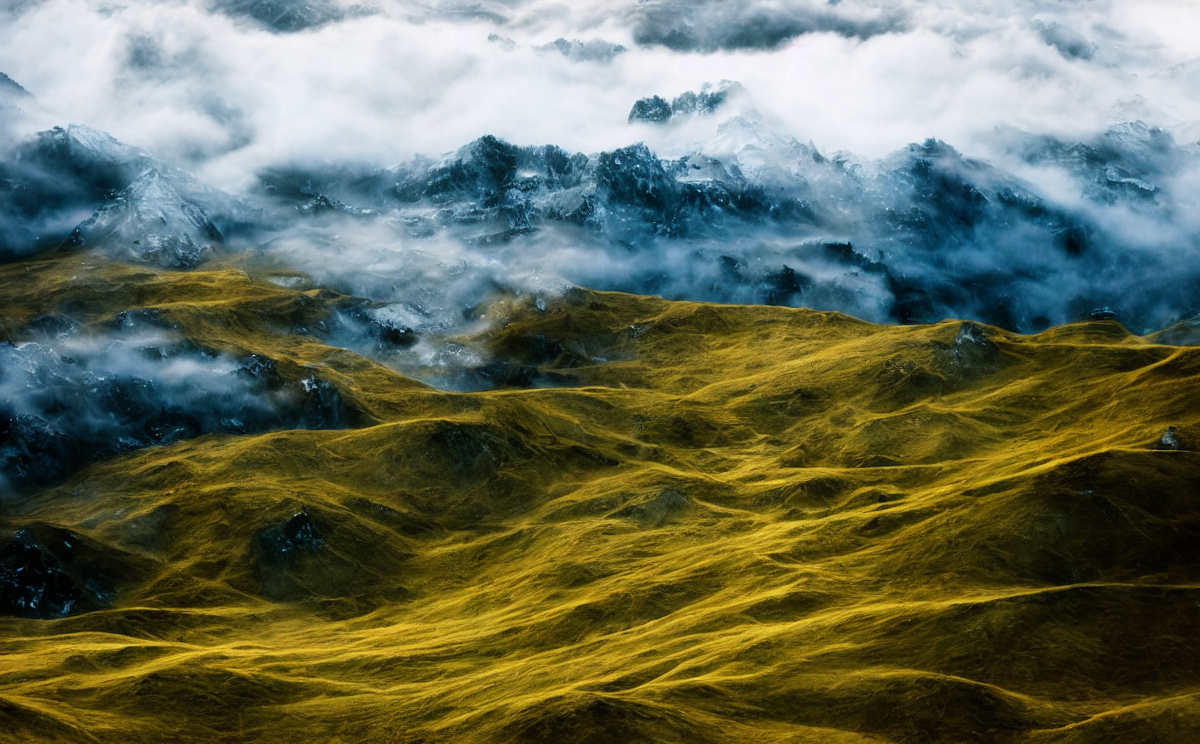

In [ ]:
result